Jonathon Tucker Final Project

# Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import re
import io
from IPython.display import display as ipy_display, Image as IPyImage

## Transformers

In [2]:
transform = torchvision.transforms.Compose([torchvision.transforms.ToTensor(), torchvision.transforms.Normalize((0.5,), (0.5,))]) #transform image data into tensors (mean 0.5 sd 0.5)

train_set = torchvision.datasets.MNIST(root='~/.pytorch/MNIST_data/', train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root='~/.pytorch/MNIST_data/', train=False, download=True, transform=transform)


train_loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=32, shuffle=False)

## Examine MINST Data

In [3]:
#Examine Data Set
print('Number of images in the training dataset:', len(train_set))
print('Number of images in the testing dataset:', len(test_set))
print(f"Shape of the images in the training dataset: {train_loader.dataset[0][0].shape}")

Number of images in the training dataset: 60000
Number of images in the testing dataset: 10000
Shape of the images in the training dataset: torch.Size([1, 28, 28])


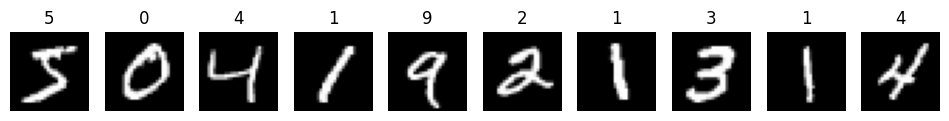

In [4]:
# First 10 images of training set
fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i in range(10):
    axes[i].imshow(train_loader.dataset[i][0].squeeze(), cmap='gray')
    axes[i].set_title(train_loader.dataset[i][1])
    axes[i].axis('off')
plt.show()

# BuildNN — Neural Network Foundations

## Manual Neural Network Construction

Before using PyTorch's `nn` module, let's see how the feedforward process works with raw matrix operations.

In [5]:
torch.manual_seed(7)

n_input  = 28 * 28 #784 input values
n_hidden = 128     #first hidden 128 neurons
n_output = 10      #10 activations

#add another hidden layer and activation vaules per HL 


#change weights and bias for different results 
W1 = torch.randn(n_input, n_hidden)
W2 = torch.randn(n_hidden, n_output)
B1 = torch.randn((1, n_hidden))
B2 = torch.randn((1, n_output))

def activation(x):
    return 1 / (1 + torch.exp(-x))

def manual_output(features, weights, bias):
    return activation(torch.mm(features, weights) + bias)

dataiter = iter(train_loader)
sample_images, sample_labels = next(dataiter)

images_flatten = sample_images.view(sample_images.shape[0], -1)
h   = manual_output(images_flatten, W1, B1)
out = manual_output(h, W2, B2)
print('Hidden shape:', h.shape)
print('Output shape:', out.shape)

Hidden shape: torch.Size([32, 128])
Output shape: torch.Size([32, 10])


## Softmax Function

Softmax squishes each output between 0 and 1 and normalizes so the values sum to a probability distribution.
$$\sigma(x_i) = \cfrac{e^{x_i}}{\sum_k^n{e^{x_k}}}$$

In [6]:
def softmax(x):
    return torch.exp(x) / torch.sum(torch.exp(x), dim=1).view(-1, 1)

probabilities = softmax(out)
print('Probabilities shape:', probabilities.shape)
print('Row sums (should all be 1):', probabilities.sum(dim=1)[:5])

Probabilities shape: torch.Size([32, 10])
Row sums (should all be 1): tensor([1., 1., 1., 1., 1.])


## Building with `nn.Module`

PyTorch's `nn` module provides a cleaner way to define networks. Here's the same architecture using `nn.Module` with sigmoid activation.

In [7]:
class NetworkSigmoid(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(784, 128)
        self.output = nn.Linear(128, 10)
        self.sigmoid = nn.Sigmoid()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.hidden(x)
        x = self.sigmoid(x)
        x = self.output(x)
        x = self.softmax(x)
        return x

net_sigmoid = NetworkSigmoid()
print(net_sigmoid)

NetworkSigmoid(
  (hidden): Linear(in_features=784, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=10, bias=True)
  (sigmoid): Sigmoid()
  (softmax): Softmax(dim=1)
)


## Functional API

Using `torch.nn.functional` (imported as `F`) is more concise and the most common style you'll see in practice.

In [8]:
class NetworkFunctional(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(784, 128)
        self.output = nn.Linear(128, 10)

    def forward(self, x):
        x = F.sigmoid(self.hidden(x))
        x = F.softmax(self.output(x), dim=1)
        return x

net_functional = NetworkFunctional()
print(net_functional)

NetworkFunctional(
  (hidden): Linear(in_features=784, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=10, bias=True)
)


## ReLU Network — fc1, fc2, output

A two-hidden-layer network using ReLU activations, matching the architecture we train below.

In [9]:
class NetworkReLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1    = nn.Linear(784, 128)
        self.fc2    = nn.Linear(128, 64)
        self.output = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.output(x), dim=1)
        return x

net_relu = NetworkReLU()
print(net_relu)
print('\nfc1 weight shape:', net_relu.fc1.weight.shape)
print('fc1 bias shape:  ', net_relu.fc1.bias.shape)

NetworkReLU(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=10, bias=True)
)

fc1 weight shape: torch.Size([128, 784])
fc1 bias shape:   torch.Size([128])


## Weight Initialization

Weights are auto-initialized, but you can customize them via the `.data` tensor.

In [10]:
net_relu.fc1.bias.data.fill_(0)
net_relu.fc1.weight.data.normal_(std=0.01)
print('Biases zeroed:', net_relu.fc1.bias.data[:5])
print('Weights re-init (std=0.01):', net_relu.fc1.weight.data[0, :5])

Biases zeroed: tensor([0., 0., 0., 0., 0.])
Weights re-init (std=0.01): tensor([-0.0137, -0.0004, -0.0186, -0.0093,  0.0120])


## Feed-Forward Pass (Before Training)

With random weights the outputs are nearly uniform — no useful predictions yet.

In [11]:
net_relu.eval()
sample_images.resize_(sample_images.shape[0], 1, 784)
with torch.no_grad():
    ps = net_relu.forward(sample_images[0, :])
print('Output probabilities (random weights):')
print(ps)

Output probabilities (random weights):
tensor([[0.1061, 0.0834, 0.0876, 0.1045, 0.1119, 0.0918, 0.1009, 0.0937, 0.1150,
         0.1051]])


## `nn.Sequential`

For straightforward stacks, `nn.Sequential` lets you skip writing a class entirely.

In [12]:
input_size   = 784
hidden_sizes = [128, 64]
output_size  = 10

net_sequential = nn.Sequential(
    nn.Linear(input_size, hidden_sizes[0]),
    nn.ReLU(),
    nn.Linear(hidden_sizes[0], hidden_sizes[1]),
    nn.ReLU(),
    nn.Linear(hidden_sizes[1], output_size),
    nn.Softmax(dim=1)
)
print(net_sequential)

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
  (5): Softmax(dim=1)
)


## Named Layers with `OrderedDict`

Pass an `OrderedDict` to `nn.Sequential` to give each layer a readable name.

In [13]:
from collections import OrderedDict

net_named = nn.Sequential(OrderedDict([
    ('fc1',     nn.Linear(input_size, hidden_sizes[0])),
    ('relu1',   nn.ReLU()),
    ('fc2',     nn.Linear(hidden_sizes[0], hidden_sizes[1])),
    ('relu2',   nn.ReLU()),
    ('output',  nn.Linear(hidden_sizes[1], output_size)),
    ('softmax', nn.Softmax(dim=1))
]))
print(net_named)
print('\nAccess by index:', net_named[0])
print('Access by name: ', net_named.fc1)

Sequential(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=64, out_features=10, bias=True)
  (softmax): Softmax(dim=1)
)

Access by index: Linear(in_features=784, out_features=128, bias=True)
Access by name:  Linear(in_features=784, out_features=128, bias=True)


### BELOW IS NOT ON BUILD NN

# Train NN

In [29]:
# Training
loss_function = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5
for epoch in range(epochs):
    for images, labels in train_loader:
        optimizer.zero_grad()

        output = model(images)
        loss = loss_function(output, labels)
        
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [1/5], Loss: 0.0521
Epoch [2/5], Loss: 0.0056
Epoch [3/5], Loss: 0.0943
Epoch [4/5], Loss: 0.0543
Epoch [5/5], Loss: 0.0045


In [30]:
def view_classify(image, probabilities):
    probabilities = probabilities.data.numpy().squeeze()

    fig, (ax1, ax2) = plt.subplots(figsize=(6,9), ncols=2)
    ax1.imshow(image.numpy().squeeze())
    ax1.axis('off')
    ax2.barh(np.arange(10), probabilities)
    ax2.set_aspect(0.1)
    ax2.set_yticks(np.arange(10))
    ax2.set_yticklabels(np.arange(10))
    ax2.set_title('Class Probability')
    ax2.set_xlim(0, 1.1)
    plt.tight_layout()

In [31]:
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        output = model(images)
        _, predicted = torch.max(output, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
print(f'Accuracy of the neural network on the {total} test images: {100 * correct / total}%')

Accuracy of the neural network on the 10000 test images: 97.14%


# Test Model

In [38]:
# Run test on class dataset
model.eval()
with torch.no_grad():
    output = model(class_images)
    _, predicted = torch.max(output, 1)

correct = (predicted == class_labels).sum().item()
total = len(class_labels)
print(f'Accuracy on class dataset: {100 * correct / total:.2f}% ({correct}/{total})')
print()
print('Per-digit accuracy:')
for digit in range(10):
    mask = class_labels == digit
    if mask.sum() > 0:
        d_correct = (predicted[mask] == class_labels[mask]).sum().item()
        d_total = mask.sum().item()
        print(f'  Digit {digit}: {d_correct}/{d_total} ({100*d_correct/d_total:.1f}%)')

Accuracy on class dataset: 54.14% (157/290)

Per-digit accuracy:
  Digit 0: 15/29 (51.7%)
  Digit 1: 14/29 (48.3%)
  Digit 2: 22/29 (75.9%)
  Digit 3: 23/29 (79.3%)
  Digit 4: 22/29 (75.9%)
  Digit 5: 18/29 (62.1%)
  Digit 6: 16/29 (55.2%)
  Digit 7: 6/29 (20.7%)
  Digit 8: 12/29 (41.4%)
  Digit 9: 9/29 (31.0%)


In [35]:
from sklearn.metrics import f1_score, log_loss

y_true = class_labels.numpy()
y_pred = predicted.numpy()
probs  = torch.exp(output).numpy()

f1_macro = f1_score(y_true, y_pred, average='macro')
f1_per   = f1_score(y_true, y_pred, average=None)
print(f'F1 Score (macro): {f1_macro:.4f}')
print()
print('F1 per digit:')
for d, f in enumerate(f1_per):
    print(f'  Digit {d}: {f:.4f}')

F1 Score (macro): 0.5314

F1 per digit:
  Digit 0: 0.6522
  Digit 1: 0.4516
  Digit 2: 0.6027
  Digit 3: 0.6479
  Digit 4: 0.6377
  Digit 5: 0.5455
  Digit 6: 0.5517
  Digit 7: 0.2400
  Digit 8: 0.5455
  Digit 9: 0.4390


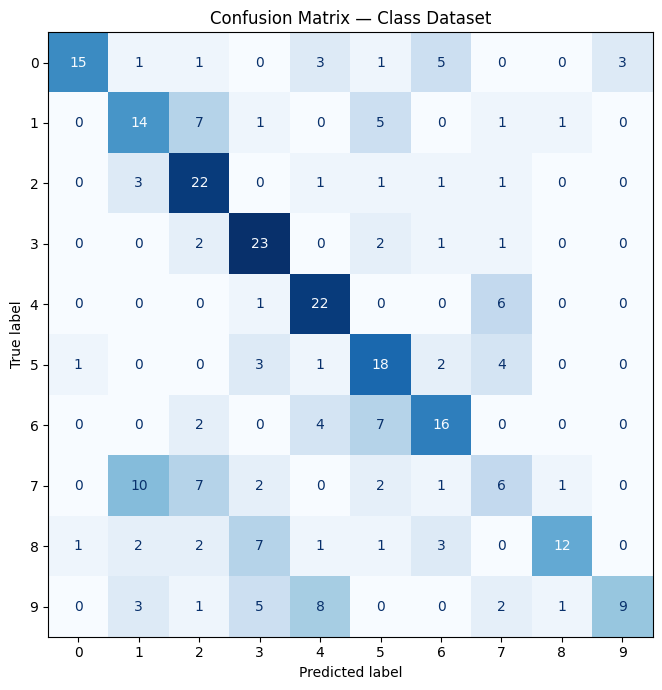

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Class Dataset')
plt.tight_layout()
plt.show()

In [37]:
ll = log_loss(y_true, probs)
print(f'Log-loss: {ll:.4f}')

Log-loss: 2.3048
